In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline  
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import locale
locale.setlocale(locale.LC_TIME, "pt_PT") # processar datas em PT
import aosol.series.consumo as series
import aosol.series.producao as seriesprod
import aosol.series.pvgis as pvgis
import aosol.analise.analise_energia as ae
import aosol.analise.analise_financeira as af
import aosol.analise.analise_precos_energia as ape
from aosol.armazenamento.bateria import bateria
from tabulate import tabulate

# Estudo UPAC para diferentes parâmetros

Qual o melhor tamanho de UPAC com e sem bateria (r_pv e r_bat) para diferentes parâmetros:

* consumo: baixo (1200 kWh/ano), médio (3600 kWh/ano) e alto (9600 kWh/ano)
* tarifário: simples ou bihorário. Indexado?
* Preço unitário de bateria €/kWh, entre 100 e 500€
* Zona do país : Porto, Lisboa e Faro


O tamanho da UPAC é normalizado pelo consumo anual. Para perfil de consumo é utilizado o perfis da E-REDES para 2025.

$r_{pv} = \frac{Producao_{PV}}{Consumo} \left[ \frac{kWh}{kWh} \right]$

$r_{bat} = \frac{CAP_{bat}}{Consumo} \left[ \frac{kWh}{MWh} \right]$

Os perfis de produção são obtidos do PVGIS.

In [3]:
# =====================
# Consumo
# =====================
ano_consumo = 2023
perfil = 'BTN C' # ver na document
consumo_anual_baixo = 1200 # 100 kWh/mes
consumo_anual_medio = 3600 # 300 kWh/mes
consumo_anual_alto = 9600  # 800 kWh/mes
fich_perfil_eredes = r"./consumo/perfis_eredes/E-REDES_Perfil_Consumo_2023.csv"

# =====================
# Producao
# =====================
ano_producao = 2023 # converter as datas de producao para este ano
# Opcoes API PVGIS
inicio_ano_pvgis = 2005
fim_ano_pvgis = 2023 # PVGIS-SARAH3 na V5.3 (2005-2023)
inclinacao = 30
azimute = 0.0 # azimute = 180 + x; 0 = Sul
perdas = 14 # %
# Porto
lat1 = 41.156
lon1 = -8.621
# Lisboa
lat2 = 38.736
lon2 = -9.143
# Faro
lat3 = 37.027
lon3 = -7.934



# params_sistema_com_bateria = {
#     "consumo_anual" : consumo_anual,
#     "eficiencia_inversor" : 0.96,
#     "eficiencia_bateria" : 0.92,
#     "soc_min" : 0.1,
#     "soc_max" : 0.9,
#     "pot_maxima" : 5 # kW
# }



## Consumo

Perfis de consumo E-REDES para 2023. Perfil escalado para 3 valores:
* baixo (1200 kWh/ano - 100 kWh/mes)
* medio (3600 kWh/ano - 300 kWh/mes)
* alto  (9600 kWh/ano - 500 kWh/mes)

In [4]:
perfil_eredes = series.leitura_perfis_eredes(fich_perfil_eredes, perfil)
consumo = series.ajustar_perfil_eredes_a_consumo_anual(perfil_eredes, 1000, 'BTN C', 'consumo')
consumo_baixo = series.ajustar_perfil_eredes_a_consumo_anual(perfil_eredes, consumo_anual_baixo, 'BTN C', 'consumo')
consumo_medio = series.ajustar_perfil_eredes_a_consumo_anual(perfil_eredes, consumo_anual_medio, 'BTN C', 'consumo')
consumo_alto = series.ajustar_perfil_eredes_a_consumo_anual(perfil_eredes, consumo_anual_alto, 'BTN C', 'consumo')

Perfis de consumo por hora do dia e mês do ano para perfil normalizado (1000 kWh/ano)

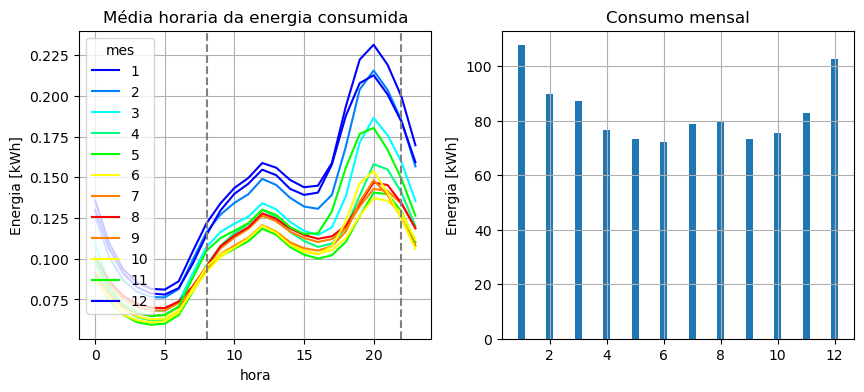

In [5]:
consumo_12_24 = ae.calcula_12x24(consumo, 'consumo')
consumo_mensal = consumo['consumo'].resample('M').sum()

colors = [
    (0, 0, 1),  # January (Blue - Winter)
    (0, 0.5, 1),  # February
    (0, 1, 1),  # March
    (0, 1, 0.5),  # April
    (0, 1, 0),  # May
    (1, 1, 0),  # June
    (1, 0.5, 0),  # July (Red - Peak Summer)
    (1, 0, 0),  # August (Deep Red)
    (1, 0.5, 0),  # September
    (1, 1, 0),  # October
    (0, 1, 0),  # November
    (0, 0, 1)   # December (Back to Blue - Winter)
]
cyclic_colormap = mcolors.LinearSegmentedColormap.from_list("seasonal_cycle", colors, N=12)

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
consumo_12_24.plot(color=[cyclic_colormap(i) for i in range(12)], ax=ax[0])
ax[0].grid()
ax[0].set_ylabel('Energia [kWh]')
ax[0].axvline(x=8, color='grey', linestyle='--')
ax[0].axvline(x=22, color='grey', linestyle='--')
ax[0].set_title('Média horaria da energia consumida')

width = 0.25
ax[1].bar(consumo_mensal.index.month, consumo_mensal, width=width, label='Consumo')
ax[1].set_title('Consumo mensal')
ax[1].set_ylabel('Energia [kWh]')
ax[1].grid()


## Preços de energia

Custo total de 1 kWh consumido da rede, incluindo TAR, taxas e iva

Opções obtidas do simulador Tiago Felicia à data 13/06


### Simples : EDP

In [6]:
custo_ene = dict()
custo_ene["simples"] = dict()

# EDP : SIMPLES
c_tar = 0.06
c_energia = 0.0740
t_tarifa_social = 0.001657
t_especial_consumo = 0.001

c_iva = (c_energia + c_tar) * 0.06 + (t_tarifa_social + t_especial_consumo) * 0.23
c_taxas = t_tarifa_social + t_especial_consumo
c_total = c_energia + c_tar + c_taxas + c_iva

custo_ene["simples"]["custo energia"] = c_energia
custo_ene["simples"]["custo rede"] = c_tar
custo_ene["simples"]["taxas e impostos"] = c_taxas + c_iva
custo_ene["simples"]["total"] = c_total
print(f"Custo total simples = {c_total:.4f} €/kWH")

Custo total simples = 0.1453 €/kWH


### Bihorario : Gold Energy

In [7]:
c_tar = 0.0149
c_energia = 0.0787
t_tarifa_social = 0.001657
t_especial_consumo = 0.001

c_iva = (c_energia + c_tar) * 0.06 + (t_tarifa_social + t_especial_consumo) * 0.23
c_taxas = t_tarifa_social + t_especial_consumo
c_total = c_energia + c_tar + c_taxas + c_iva

custo_ene["bihorario"] = dict()
custo_ene["bihorario"]["vazio energia"] = c_energia
custo_ene["bihorario"]["vazio rede"] = c_tar
custo_ene["bihorario"]["vazio taxas e impostos"] = c_taxas + c_iva
custo_ene["bihorario"]["vazio total"] = c_total
print(f"Custo bihorario vazio = {c_total:.4f} €/kWh")

c_tar = 0.0830
c_energia = 0.1011
t_tarifa_social = 0.001657
t_especial_consumo = 0.001

c_iva = (c_energia + c_tar) * 0.06 + (t_tarifa_social + t_especial_consumo) * 0.23
c_taxas = t_tarifa_social + t_especial_consumo
c_total = c_energia + c_tar + c_taxas + c_iva
custo_ene["bihorario"]["fora vazio energia"] = c_energia
custo_ene["bihorario"]["fora vazio rede"] = c_tar
custo_ene["bihorario"]["fora vazio taxas e impostos"] = c_taxas + c_iva
custo_ene["bihorario"]["fora vazio total"] = c_total
print(f"Custo bihorario fora vazio = {c_total:.4f} €/kWh")


Custo bihorario vazio = 0.1025 €/kWh
Custo bihorario fora vazio = 0.1984 €/kWh


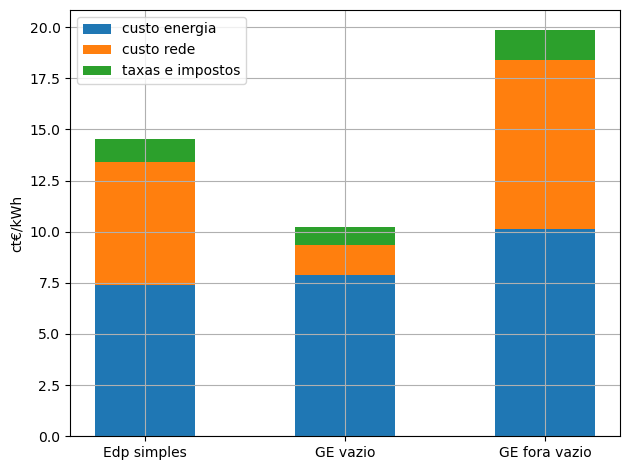

In [8]:
comercializadores = ["Edp simples", "GE vazio", "GE fora vazio"]
energia_arr = np.array([custo_ene["simples"]["custo energia"], custo_ene["bihorario"]["vazio energia"], custo_ene["bihorario"]["fora vazio energia"] ])
bar1 = plt.bar(comercializadores, energia_arr*100, width=0.5, label="custo energia")

rede_arr = np.array([custo_ene["simples"]["custo rede"], custo_ene["bihorario"]["vazio rede"], custo_ene["bihorario"]["fora vazio rede"]])
bar2 = plt.bar(comercializadores, rede_arr*100, bottom=energia_arr*100, width=0.5, label="custo rede")

taxas_arr = np.array([custo_ene["simples"]["taxas e impostos"], custo_ene["bihorario"]["vazio taxas e impostos"], custo_ene["bihorario"]["fora vazio taxas e impostos"]])
bar3 = plt.bar(comercializadores, taxas_arr*100, bottom=(energia_arr+rede_arr)*100, width=0.5, label="taxas e impostos")
plt.ylabel("ct€/kWh")
plt.legend()
plt.tight_layout()
plt.grid()


## Produção

Perfil de produção do PVGIS para 1 kWp instalado em 3 localizações de Portugal:
* Norte : Porto
* Centro : Lisboa
* Sul : Faro

Todos os sistemas virados a sul, com inclinação de 30º e com perdas de 14% (valor por defeito do PVGIS)

In [9]:
producao_porto = pvgis.get_pvgis_hourly(lat1, lon1, inicio_ano_pvgis, fim_ano_pvgis, surface_tilt=inclinacao, surface_azimuth=azimute, peakpower=1, loss=perdas)
producao_porto = seriesprod.converter_pvgis_multiyear_ts(producao_porto, ano_producao)

producao_lisboa = pvgis.get_pvgis_hourly(lat2, lon2, inicio_ano_pvgis, fim_ano_pvgis, surface_tilt=inclinacao, surface_azimuth=azimute, peakpower=1, loss=perdas)
producao_lisboa = seriesprod.converter_pvgis_multiyear_ts(producao_lisboa, ano_producao)

producao_faro = pvgis.get_pvgis_hourly(lat3, lon3, inicio_ano_pvgis, fim_ano_pvgis, surface_tilt=inclinacao, surface_azimuth=azimute, peakpower=1, loss=perdas)
producao_faro = seriesprod.converter_pvgis_multiyear_ts(producao_faro, ano_producao)

NEPS Porto = 1461 h
NEPS Lisboa = 1593 h
NEPS Faro = 1672 h


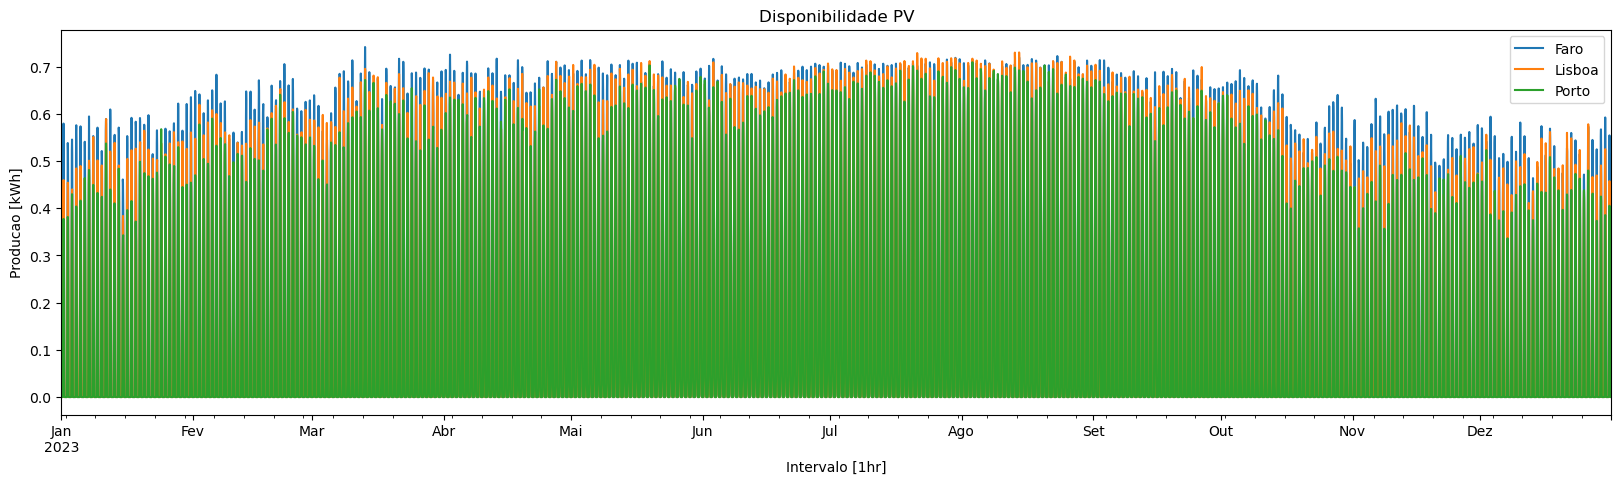

In [10]:
p,ax = plt.subplots(1,1, figsize=(20,5))
producao_faro["autoproducao"].plot(ax=ax, label='Faro')
producao_lisboa["autoproducao"].plot(ax=ax, label='Lisboa')
producao_porto["autoproducao"].plot(ax=ax, label='Porto')
plt.legend()
plt.ylabel('Producao [kWh]')
plt.xlabel('Intervalo [1hr]')
plt.title('Disponibilidade PV')

print(f"NEPS Porto = {producao_porto['autoproducao'].sum():.0f} h")
print(f"NEPS Lisboa = {producao_lisboa['autoproducao'].sum():.0f} h")
print(f"NEPS Faro = {producao_faro['autoproducao'].sum():.0f} h")

## Estudo UPAV sem bateria para tarifário simples e bihorario

Estudo de sistema com $0 \leq r_{PV} \leq 3$. Desde sem instalação de PV até sistema que produz 3x o consumo anual.

In [11]:
# =====================
# Sistema
# =====================
params_sistema_sem_bateria_baixo = {
    "consumo_anual" : consumo_anual_baixo,
    "eficiencia_inversor" : 0.96
}

params_sistema_sem_bateria_medio = {
    "consumo_anual" : consumo_anual_medio,
    "eficiencia_inversor" : 0.96
}

params_sistema_sem_bateria_alto = {
    "consumo_anual" : consumo_anual_alto,
    "eficiencia_inversor" : 0.96
}

# =====================
# Custos
# =====================
params_financeiros = {
    "tempo_vida": 20,
    "tempo_vida_bat": 0,
    "pv_por_kW": 1000,
    "bat_por_kwh": 0,
    "perc_custo_manutencao": 0.5, # em %
    "taxa_actualizacao": 3,   # em %
    "simples_kWh": custo_ene["simples"]["total"],
    "vazio_kWh": custo_ene["bihorario"]["vazio total"],
    "fora_vazio_kWh": custo_ene["bihorario"]["fora vazio total"],
    "preco_venda_rede": 0.04  # 4cent/kWh
}

# precos energia
preco_venda_rede= 0.04 # 4cent/kWh

In [12]:
simples_porto_baixo, c = ae.estudo_upac_sem_bateria(consumo_baixo, producao_porto, params_sistema_sem_bateria_baixo, ape.Tarifario.Simples, params_financeiros)
simples_porto_medio, c = ae.estudo_upac_sem_bateria(consumo_medio, producao_porto, params_sistema_sem_bateria_medio, ape.Tarifario.Simples, params_financeiros)
simples_porto_alto, c = ae.estudo_upac_sem_bateria(consumo_alto, producao_porto, params_sistema_sem_bateria_alto, ape.Tarifario.Simples, params_financeiros)

simples_lisboa_baixo, c = ae.estudo_upac_sem_bateria(consumo_baixo, producao_lisboa, params_sistema_sem_bateria_baixo, ape.Tarifario.Simples, params_financeiros)
simples_lisboa_medio, c = ae.estudo_upac_sem_bateria(consumo_medio, producao_lisboa, params_sistema_sem_bateria_medio, ape.Tarifario.Simples, params_financeiros)
simples_lisboa_alto, c = ae.estudo_upac_sem_bateria(consumo_alto, producao_lisboa, params_sistema_sem_bateria_alto, ape.Tarifario.Simples, params_financeiros)

simples_faro_baixo, c = ae.estudo_upac_sem_bateria(consumo_baixo, producao_faro, params_sistema_sem_bateria_baixo, ape.Tarifario.Simples, params_financeiros)
simples_faro_medio, c = ae.estudo_upac_sem_bateria(consumo_medio, producao_faro, params_sistema_sem_bateria_medio, ape.Tarifario.Simples, params_financeiros)
simples_faro_alto, c = ae.estudo_upac_sem_bateria(consumo_alto, producao_faro, params_sistema_sem_bateria_alto, ape.Tarifario.Simples, params_financeiros)

In [13]:
bihorario_porto_baixo, _ = ae.estudo_upac_sem_bateria(consumo_baixo, producao_porto, params_sistema_sem_bateria_baixo, ape.Tarifario.Bihorario, params_financeiros)
bihorario_porto_medio, preco_medio_porto = ae.estudo_upac_sem_bateria(consumo_medio, producao_porto, params_sistema_sem_bateria_medio, ape.Tarifario.Bihorario, params_financeiros)
bihorario_porto_alto, _ = ae.estudo_upac_sem_bateria(consumo_alto, producao_porto, params_sistema_sem_bateria_alto, ape.Tarifario.Bihorario, params_financeiros)

bihorario_lisboa_baixo, _ = ae.estudo_upac_sem_bateria(consumo_baixo, producao_lisboa, params_sistema_sem_bateria_baixo, ape.Tarifario.Bihorario, params_financeiros)
bihorario_lisboa_medio, preco_medio_lisboa = ae.estudo_upac_sem_bateria(consumo_medio, producao_lisboa, params_sistema_sem_bateria_medio, ape.Tarifario.Bihorario, params_financeiros)
bihorario_lisboa_alto, _ = ae.estudo_upac_sem_bateria(consumo_alto, producao_lisboa, params_sistema_sem_bateria_alto, ape.Tarifario.Bihorario, params_financeiros)

bihorario_faro_baixo, _ = ae.estudo_upac_sem_bateria(consumo_baixo, producao_faro, params_sistema_sem_bateria_baixo, ape.Tarifario.Bihorario, params_financeiros)
bihorario_faro_medio, preco_medio_faro = ae.estudo_upac_sem_bateria(consumo_medio, producao_faro, params_sistema_sem_bateria_medio, ape.Tarifario.Bihorario, params_financeiros)
bihorario_faro_alto, _ = ae.estudo_upac_sem_bateria(consumo_alto, producao_faro, params_sistema_sem_bateria_alto, ape.Tarifario.Bihorario, params_financeiros)

Comparação de cenário com venda do excesso à rede ou sem venda para cada uma das localizações.

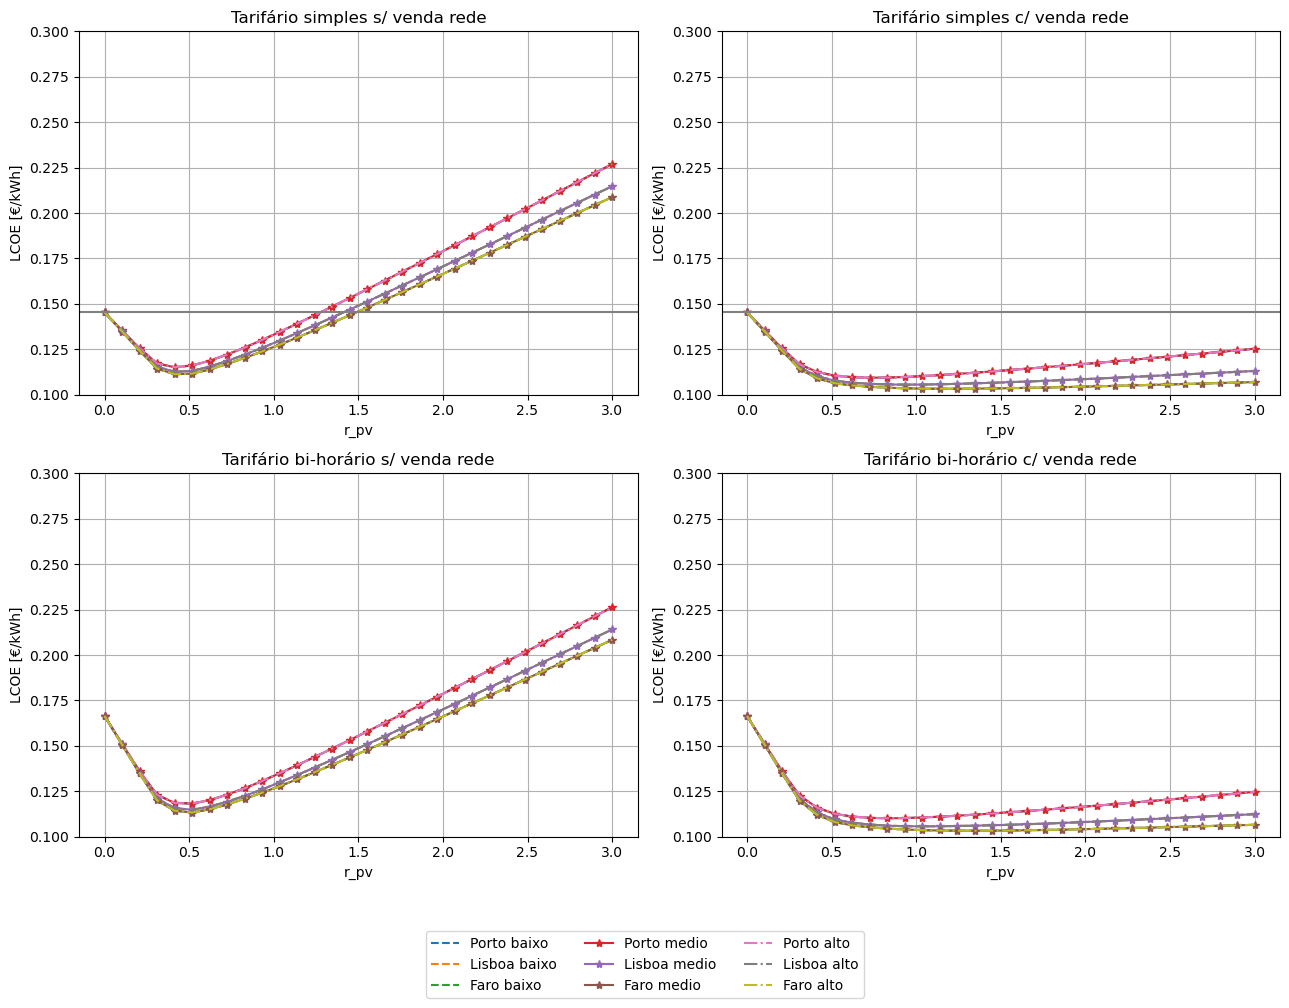

In [14]:
%matplotlib inline
fig, ax = plt.subplots(2, 2, figsize=(13, 10), sharex=False)

simples_porto_baixo.plot(y=["lcoe s/ venda"], style='--', label=['Porto baixo'], ax=ax[0,0])
simples_lisboa_baixo.plot(y=["lcoe s/ venda"], style='--', label=['Lisboa baixo'], ax=ax[0,0])
simples_faro_baixo.plot(y=["lcoe s/ venda"], style='--', label=['Faro baixo'], ax=ax[0,0])

simples_porto_medio.plot(y=["lcoe s/ venda"], style='-*', label=['Porto medio'], ax=ax[0,0])
simples_lisboa_medio.plot(y=["lcoe s/ venda"], style='-*', label=['Lisboa medio'], ax=ax[0,0])
simples_faro_medio.plot(y=["lcoe s/ venda"], style='-*', label=['Faro medio'], ax=ax[0,0])

simples_porto_alto.plot(y=["lcoe s/ venda"], style='-.', label=['Porto alto'], ax=ax[0,0])
simples_lisboa_alto.plot(y=["lcoe s/ venda"], style='-.', label=['Lisboa alto'], ax=ax[0,0])
simples_faro_alto.plot(y=["lcoe s/ venda"], style='-.', label=['Faro alto'], ax=ax[0,0])

ax[0,0].set_title('Tarifário simples s/ venda rede')
ax[0,0].set_ylabel("LCOE [€/kWh]")
ax[0,0].grid()
ax[0,0].legend().remove()
ax[0,0].axhline(y=custo_ene["simples"]["total"], color='grey')
ax[0,0].set_ylim(0.1, 0.3)

simples_porto_baixo.plot(y=["lcoe c/ venda"], style='--', label=['Porto baixo'], ax=ax[0,1])
simples_lisboa_baixo.plot(y=["lcoe c/ venda"], style='--', label=['Lisboa baixo'], ax=ax[0,1])
simples_faro_baixo.plot(y=["lcoe c/ venda"], style='--', label=['Faro baixo'], ax=ax[0,1])

simples_porto_medio.plot(y=["lcoe c/ venda"], style='-*', label=['Porto medio'], ax=ax[0,1])
simples_lisboa_medio.plot(y=["lcoe c/ venda"], style='-*', label=['Lisboa medio'], ax=ax[0,1])
simples_faro_medio.plot(y=["lcoe c/ venda"], style='-*', label=['Faro medio'], ax=ax[0,1])

simples_porto_alto.plot(y=["lcoe c/ venda"], style='-.', label=['Porto alto'], ax=ax[0,1])
simples_lisboa_alto.plot(y=["lcoe c/ venda"], style='-.', label=['Lisboa alto'], ax=ax[0,1])
simples_faro_alto.plot(y=["lcoe c/ venda"], style='-.', label=['Faro alto'], ax=ax[0,1])

ax[0,1].set_title('Tarifário simples c/ venda rede')
ax[0,1].set_ylabel("LCOE [€/kWh]")
ax[0,1].grid()
ax[0,1].legend().remove()
ax[0,1].axhline(y=custo_ene["simples"]["total"], color='grey')
ax[0,1].set_ylim(0.1, 0.3)

bihorario_porto_baixo.plot(y=["lcoe s/ venda"], style='--', label=['Porto baixo'], ax=ax[1,0])
bihorario_lisboa_baixo.plot(y=["lcoe s/ venda"], style='--', label=['Lisboa baixo'], ax=ax[1,0])
bihorario_faro_baixo.plot(y=["lcoe s/ venda"], style='--', label=['Faro baixo'], ax=ax[1,0])

bihorario_porto_medio.plot(y=["lcoe s/ venda"], style='-*', label=['Porto medio'], ax=ax[1,0])
bihorario_lisboa_medio.plot(y=["lcoe s/ venda"], style='-*', label=['Lisboa medio'], ax=ax[1,0])
bihorario_faro_medio.plot(y=["lcoe s/ venda"], style='-*', label=['Faro medio'], ax=ax[1,0])

bihorario_porto_alto.plot(y=["lcoe s/ venda"], style='-.', label=['Porto alto'], ax=ax[1,0])
bihorario_lisboa_alto.plot(y=["lcoe s/ venda"], style='-.', label=['Lisboa alto'], ax=ax[1,0])
bihorario_faro_alto.plot(y=["lcoe s/ venda"], style='-.', label=['Faro alto'], ax=ax[1,0])

ax[1,0].set_title('Tarifário bi-horário s/ venda rede')
ax[1,0].set_ylabel("LCOE [€/kWh]")
ax[1,0].grid()
ax[1,0].legend().remove()
#ax[1,0].axhline(y=custo_ene["bihorario"]["total"], color='grey')
ax[1,0].set_ylim(0.1, 0.3)

bihorario_porto_baixo.plot(y=["lcoe c/ venda"], style='--', label=['Porto baixo'], ax=ax[1,1])
bihorario_lisboa_baixo.plot(y=["lcoe c/ venda"], style='--', label=['Lisboa baixo'], ax=ax[1,1])
bihorario_faro_baixo.plot(y=["lcoe c/ venda"], style='--', label=['Faro baixo'], ax=ax[1,1])

bihorario_porto_medio.plot(y=["lcoe c/ venda"], style='-*', label=['Porto medio'], ax=ax[1,1])
bihorario_lisboa_medio.plot(y=["lcoe c/ venda"], style='-*', label=['Lisboa medio'], ax=ax[1,1])
bihorario_faro_medio.plot(y=["lcoe c/ venda"], style='-*', label=['Faro medio'], ax=ax[1,1])

bihorario_porto_alto.plot(y=["lcoe c/ venda"], style='-.', label=['Porto alto'], ax=ax[1,1])
bihorario_lisboa_alto.plot(y=["lcoe c/ venda"], style='-.', label=['Lisboa alto'], ax=ax[1,1])
bihorario_faro_alto.plot(y=["lcoe c/ venda"], style='-.', label=['Faro alto'], ax=ax[1,1])

ax[1,1].set_title('Tarifário bi-horário c/ venda rede')
ax[1,1].set_ylabel("LCOE [€/kWh]")
ax[1,1].grid()
ax[1,1].legend().remove()
#ax[0,1].axhline(y=custo_ene["simples"]["total"], color='grey')
ax[1,1].set_ylim(0.1, 0.3)


handles, labels = ax[0,0].get_legend_handles_labels()
# Create the legend outside the subplots
fig.legend(handles=handles,loc='lower center',bbox_to_anchor=(0.5, -0.01),ncol=3, frameon=True)
plt.tight_layout(rect=[0, 0.1, 1, 1]) # Adjust layout to make space for the legend
plt.show()




## Estudo de UPAC com bateria

Estudo paramétrico para vários tamanhos de sistema onde o despacho da bateria é feito sempre que há energia disponivel na bateria.

Sistema com $0.5 \leq r_{PV} \leq 2.5$ e $0 \leq r_{bat} \leq 2$

In [15]:
import scipy.optimize as optimize
from aosol.armazenamento.bateria import bateria

In [28]:
def optimiza_autoconsumo(consumo, producao, params_sistema, params_financeiros, tarifario, max_RPV=10): 
    """ Optimização de sistema de autoconsumo.

    Optimização o sistem de autoconsumo. Com os parametros dados encontra o sistema PV com ou sem bateria que minimiza o LCOE.
    A optimização é feita usando a função minimize do scipy.optimize.
    
    Parameters
    ----------
    consumo : DataFrame
        Série temporal do consumo na coluna 'consumo'. [kWh]
    producao : DataFrame
        Série temporal da produção na coluna 'autoproducao'. [kWh]
    params_sistema : dict
        Dicionario com parametros do sistema com bateria:

        - consumo_anual: total anual. [kWh]
        - eficiencia_inversor : entre [0, 1]. [-]
        - eficiencia_bateria : eficiencia entre carga e descarga, entre [0, 1]. [-]
        - soc_min : estado de carga minimo em fraccao da capacidade, entre [0, 1]. [-]
        - soc_max : estado de carga máximo em fraccao da capacidade, entre [0, 1]. [-]
        - pot_maxima : potencia máxima que pode ser fornecida/retirada da bateria. [kW]
    params_financeiros : dict
        Dicionario com parametros financeiros para calculo custo energia:

        - tempo_vida: tempo de vida do projecto. [anos]
        - tempo_vida_bat: tempo de vida da bateria. [anos]
        - pv_por_kW: custo de cada kWp instalado de PV. [€/kW]
        - bat_por_kWh: custo de cada kWh instalado de bateria. [€/kWh]
        - reinvestir_bat: considerar reinvestimento numa 2a bateria. [bool]
        - perc_custo_manutencao: percentagem do investimento gasto em manutenção anual. [%]
        - taxa_actualização: taxa de actualização. [%]
        - simples_kWh: preço compra à rede em tarifário simples. Só usado quando tarifario = tarifario.Simples. [€/kWh]
        - vazio_kWh: preço de compra à rede em vazio no tarifario bihorario. Só usado quando tarifario = tarifario.Bihorario. [€/kWh]
        - fora_vazio_kWh: preço de compra à rede fora de vazio no tarifario bihorario. Só usado quando tarifario = tarifario.Bihorario .[€/kWh]
        - preco_venda_rede: Preco de venda da energia à rede. [€/kWh]
    tarifario : ape.Tarifario
        Simples ou Bihorario.
    max_RPV : float, optional
        Limite máximo para o r_pv. The default is 10. [-]

    Returns
    -------
    r_pv : float
        Tamanho do sistema PV. Razão entre produção anual (kWh) e consumo anual (kWh). [-] 
    r_bat : float
        Tamanho da bateria. Razão entre capacidade da bateria (kWh) e consumo anual (MWh). [-]
    LCOE : float
        Custo nivelado de energia do sistema. [€/kWh]
    """
    
    neps = producao["autoproducao"].sum()
    
    # Definição das duas funções objectivo da optimização
    def f_optim(c):
        """ Função objectivo com PV e Bateria.

        LCOE do sistema com PV e bateria.

        Parameters
        ----------
        c : list
            [r_pv, r_bat]

        Returns
        -------
        LCOE : float
            Custo nivelado de energia do sistema. [€/kWh]

        Notes
        -----
        São usadas variaveis globais:

        - neps: número equivalente de horas de sol. [h]
        - consumo: série temporal do consumo. [kWh]
        - producao: série temporal da produção. [kWh]
        - params_sistema: dicionario com parametros do sistema.
        - params_financeiros: dicionario com parametros financeiros.
        - tarifario: tarifario usado.
        """
        [r_pv,r_bat] = c
        # if the ratios are negative, set them to zero and add a penalty to the objective function
        penalty_PV = - 1E10 * np.minimum(0,r_pv)
        penalty_bat = - 1E10 * np.minimum(0,r_bat)
        r_pv = np.maximum(0,r_pv)
        r_bat = np.maximum(0,r_bat)
        
        # Calculos
        tot_producao = r_pv * params_sistema["consumo_anual"]
        pot_instalada = tot_producao / neps

        cap_bat = r_bat * (params_sistema["consumo_anual"]/1000)
        bat = bateria(cap_bat, params_sistema["soc_min"], params_sistema["soc_max"], params_sistema["eficiencia_bateria"], params_sistema["pot_maxima"])
        energia = consumo.copy()
        energia["autoproducao"] = producao["autoproducao"] * pot_instalada

        energia = ae.analisa_upac_com_armazenamento(energia, bat, eficiencia_inversor=params_sistema["eficiencia_inversor"])
        indicadores = ae.calcula_indicadores_autoconsumo(energia, pot_instalada, params_sistema["eficiencia_inversor"], bat)
        lcoe, lcos, _ = af.custo_energia_prosumidor(indicadores, tarifario, params_financeiros)
        
        #print 'PV = ' + str(r_PV) + ', BAT = ' + str(r_bat) + ', PR = ' + str(PR) + ', LCOE = ' + str(LCOE)
        return lcoe + penalty_PV + penalty_bat
            
    def f_optim_nobat(c):
        """ Função objectivo com PV e sem Bateria.

        LCOE do sistema com PV e sem bateria.

        Parameters
        ----------
        c : list
            [r_pv]

        Returns
        -------
        LCOE : float
            Custo nivelado de energia do sistema. [€/kWh]

        Notes
        -----
        São usadas variaveis globais:

        - neps: número equivalente de horas de sol. [h]
        - consumo: série temporal do consumo. [kWh]
        - producao: série temporal da produção. [kWh]
        - params_sistema: dicionario com parametros do sistema.
        - params_financeiros: dicionario com parametros financeiros.
        - tarifario: tarifario usado.
        """
        r_pv = c[0]
        r_bat = 0
        # if the ratios are negative, set them to zero and add a penalty to the objective function
        penalty_PV = - 1E10 * np.minimum(0,r_pv)
        penalty_bat = - 1E10 * np.minimum(0,r_bat)
        r_pv = np.maximum(0,r_pv)
        r_bat = np.maximum(0,r_bat)
        
        tot_producao = r_pv * params_sistema["consumo_anual"]
        pot_instalada = tot_producao / neps

        energia = consumo.copy()
        energia["autoproducao"] = producao["autoproducao"] * pot_instalada

        energia = ae.analisa_upac_sem_armazenamento(energia)
        indicadores = ae.calcula_indicadores_autoconsumo(energia, pot_instalada, params_sistema["eficiencia_inversor"])
        lcoe, _, _= af.custo_energia_prosumidor(indicadores, tarifario, params_financeiros)
        
        #print 'PV = ' + str(r_PV) + ', BAT = ' + str(r_bat) + ', PR = ' + str(PR) + ', LCOE = ' + str(LCOE)
        return lcoe + penalty_PV + penalty_bat    
  
    def f_optim_maxpv(c):
        """ Função objectivo com PV máximo e bateria.

        LCOE do sistema com PV fixo no valor máximo (max_rpv) e bateria.

        Parameters
        ----------
        c : list
            [r_bat]

        Returns
        -------
        LCOE : float
            Custo nivelado de energia do sistema. [€/kWh]

        Notes
        -----
        São usadas variaveis globais:

        - neps: número equivalente de horas de sol. [h]
        - consumo: série temporal do consumo. [kWh]
        - producao: série temporal da produção. [kWh]
        - params_sistema: dicionario com parametros do sistema.
        - params_financeiros: dicionario com parametros financeiros.
        - tarifario: tarifario usado.
        - max_rpv: valor máximo para r_pv. [-]
        """
        r_pv = max_RPV
        [r_bat] = c
        # if the ratios are negative, set them to zero and add a penalty to the objective function
        penalty_PV = - 1E10 * np.minimum(0,r_pv)
        penalty_bat = - 1E10 * np.minimum(0,r_bat)
        r_pv = np.maximum(0,r_pv)
        r_bat = np.maximum(0,r_bat)
        
        tot_producao = r_pv * params_sistema["consumo_anual"]
        pot_instalada = tot_producao / neps

        cap_bat = r_bat * (params_sistema["consumo_anual"]/1000)
        bat = bateria(cap_bat, params_sistema["soc_min"], params_sistema["soc_max"], params_sistema["eficiencia_bateria"], params_sistema["pot_maxima"])
        energia = consumo.copy()
        energia["autoproducao"] = producao["autoproducao"] * pot_instalada

        energia = ae.analisa_upac_com_armazenamento(energia, bat, eficiencia_inversor=params_sistema["eficiencia_inversor"])
        indicadores = ae.calcula_indicadores_autoconsumo(energia, pot_instalada, params_sistema["eficiencia_inversor"], bat)

        lcoe, lcos, _ = af.custo_energia_prosumidor(indicadores, tarifario, params_financeiros)
        
        #print 'PV = ' + str(r_PV) + ', BAT = ' + str(r_bat) + ', PR = ' + str(PR) + ', LCOE = ' + str(LCOE)
        return lcoe + penalty_PV + penalty_bat    
    
    # Constraints:
    cons = ({'type': 'ineq', 'fun': lambda x: x[0]},
            {'type': 'ineq', 'fun': lambda x: x[1]})
    bnds = ((0, max_RPV), (0, 10))

    # Since there are 3 discrete variants of the problem, the optimization is performed 3 times and the best one is selected
    # With PV and Battery:
    result = optimize.minimize(f_optim, [0.4,1.1], method='Nelder-Mead', tol=1e-5, constraints=cons, bounds=bnds) #.values()
    # With PV, without Battery
    result2 = optimize.minimize(f_optim_nobat, [0.4], method='Nelder-Mead', tol=1e-5, constraints=cons, bounds=bnds)# .values()
    # Without PV, without battery:
    energia = consumo.copy()
    energia["autoproducao"] = producao["autoproducao"] * 0
    energia = ae.analisa_upac_sem_armazenamento(energia)
    indicadores = ae.calcula_indicadores_autoconsumo(energia, 0, params_sistema["eficiencia_inversor"])
    params_financeiros["invest_pv"] = 0
    params_financeiros["invest_bat"] = 0
    lcoe_sem_pv, _, _ = af.custo_energia_prosumidor(indicadores, tarifario, params_financeiros)

    # Selecting the best solution:
    if lcoe_sem_pv <= result2.fun and lcoe_sem_pv <= result.fun:
        r_pv = 0
        r_bat = 0
        LCOE = lcoe_sem_pv
    elif result2.fun <= lcoe_sem_pv and result2.fun <= result.fun:
        r_pv = result2.x[0]
        r_bat = 0
        LCOE = result2.fun
    elif result.fun <= lcoe_sem_pv and result.fun <= result2.fun:
        r_pv = result.x[0]
        r_bat = result.x[1]
        LCOE = result.fun

    # if r_PV is unbounded, do the univariate optimization with its max value
    if r_pv > max_RPV:  
        result_maxpv = optimize.minimize(f_optim_maxpv, [1.1], method='Nelder-Mead', tol=1e-5, constraints=cons, bounds=bnds) #.values()
        
        tot_producao = r_pv * params_sistema["consumo_anual"]
        pot_instalada = tot_producao / neps
        energia = consumo.copy()
        energia["autoproducao"] = producao["autoproducao"] * pot_instalada
        energia = ae.analisa_upac_sem_armazenamento(energia)
        indicadores = ae.calcula_indicadores_autoconsumo(energia, pot_instalada, params_sistema["eficiencia_inversor"])
        params_financeiros["invest_pv"] = params_financeiros["pv_por_kW"] * pot_instalada
        params_financeiros["invest_bat"] = 0
        lcoe_maxpv, _, _ = af.custo_energia_prosumidor(indicadores, tarifario, params_financeiros)
        
        if lcoe_maxpv <= result_maxpv[3]:
            r_pv = max_RPV
            r_bat = 0
            LCOE = lcoe_maxpv
        else:
            r_pv = max_RPV
            r_bat = result_maxpv[5][0]
            LCOE = result_maxpv[4]

    return [r_pv, r_bat, LCOE]  

def estudo_parametrico_custos_bateria(custos, consumo, producao, params_sistema, params_financeiros, tarifario, max_rpv=10):
    """ Estudo paramétrico que varia os custo da bateria e encontra o tamanho do sistema optimo que minimiza o LCOE.

    Parameters
    ----------
    custos : List[float]
        Lista com os custos da bateria a analisar. [€/kWh]
    consumo : DataFrame
        Série temporal do consumo na coluna 'consumo'. [kWh]
    producao : DataFrame
        Série temporal da produção na coluna 'autoproducao'. [kWh]
    params_sistema : dict
        Dicionario com parametros do sistema com bateria:

        - consumo_anual: total anual. [kWh]
        - eficiencia_inversor : entre [0, 1]. [-]
        - eficiencia_bateria : eficiencia entre carga e descarga, entre [0, 1]. [-]
        - soc_min : estado de carga minimo em fraccao da capacidade, entre [0, 1]. [-]
        - soc_max : estado de carga máximo em fraccao da capacidade, entre [0, 1]. [-]
        - pot_maxima : potencia máxima que pode ser fornecida/retirada da bateria. [kW]

    params_financeiros : dict
        Dicionario com parametros financeiros para calculo custo energia:

        - tempo_vida: tempo de vida do projecto. [anos]
        - tempo_vida_bat: tempo de vida da bateria. [anos]
        - pv_por_kW: custo de cada kWp instalado de PV. [€/kW]
        - bat_por_kWh: custo de cada kWh instalado de bateria. [€/kWh]
        - reinvestir_bat: considerar reinvestimento numa 2a bateria. [bool]
        - perc_custo_manutencao: percentagem do investimento gasto em manutenção anual. [%]
        - taxa_actualização: taxa de actualização. [%]
        - simples_kWh: preço compra à rede em tarifário simples. Só usado quando tarifario = tarifario.Simples. [€/kWh]
        - vazio_kWh: preço de compra à rede em vazio no tarifario bihorario. Só usado quando tarifario = tarifario.Bihorario. [€/kWh]
        - fora_vazio_kWh: preço de compra à rede fora de vazio no tarifario bihorario. Só usado quando tarifario = tarifario.Bihorario .[€/kWh]
        - preco_venda_rede: Preco de venda da energia à rede. [€/kWh]
    tarifario : ape.Tarifario
        Simples ou Bihorario.
    max_rpv : float, optional
        Limite máximo para o r_pv. The default is 10. [-]

    Returns
    -------
    resultados : DataFrame
        DataFrame com os resultados do estudo paramétrico. Contém as colunas:
        - custo_bateria: custo da bateria. [€/kWh]
        - r_pv: tamanho do sistema PV. Razão entre produção anual (kWh) e consumo anual (kWh). [-] 
        - r_bat: tamanho da bateria. Razão entre capacidade da bateria (kWh) e consumo anual (MWh). [-]
        - LCOE: custo nivelado de energia do sistema. [€/kWh]
        - LCOS: custo nivelado de armazenamento do sistema. [€/kWh]
        - ias: índice de autoconsumo. [-]
        - iac: índice de autoconsumo. [-]
        - ier: índice de energia renovável. [-]
    """
    LCOE = []
    BAT = []
    PV=[]
    LCOS = []   
    resultados = pd.DataFrame()

    for c in custos:    
        # Optimisation
        params_financeiros["bat_por_kWh"] = c
        [r_pv, r_bat, lcoe] = optimiza_autoconsumo(consumo, producao, params_sistema, params_financeiros, tarifario, max_rpv)
        #BAT.append(r_bat)    
        #LCOE.append(lcoe)
        #PV.append(r_pv)
        
        # Recalculating the whole set of values with the optimum inputs:
        neps = producao_lisboa["autoproducao"].sum()
        tot_producao = r_pv * params_sistema["consumo_anual"]
        pot_instalada = tot_producao / neps

        cap_bat = r_bat * (params_sistema["consumo_anual"]/1000)
        bat = bateria(cap_bat, params_sistema["soc_min"], params_sistema["soc_max"], params_sistema["eficiencia_bateria"], params_sistema["pot_maxima"])
        energia = consumo_medio.copy()
        energia["autoproducao"] = producao_lisboa["autoproducao"] * pot_instalada

        energia = ae.analisa_upac_com_armazenamento(energia, bat, eficiencia_inversor=params_sistema["eficiencia_inversor"])
        indicadores = ae.calcula_indicadores_autoconsumo(energia, pot_instalada, params_sistema["eficiencia_inversor"], bat)
        lcoe, lcos, _ = af.custo_energia_prosumidor(indicadores, tarifario, params_financeiros)
        #LCOE.append(lcoe)
        #LCOS.append(lcos)

        resultado = pd.DataFrame({'custo_bateria': c, 'r_pv': r_pv, 'r_bat': r_bat, 'LCOE': lcoe, 'LCOS': lcos, 'ias': indicadores.ias, 'iac': indicadores.iac, 'ier': indicadores.ier}, index=[0])
        resultados = pd.concat([resultados, resultado], ignore_index=True)

    return resultados
    #return PV, BAT, LCOE, LCOS

In [17]:
# =====================
# Sistema
# =====================
params_sistema_com_bateria_baixo = {
    "consumo_anual" : consumo_anual_baixo,
    "eficiencia_inversor" : 0.96,
    "eficiencia_bateria" : 0.92,
    "soc_min" : 0.2,
    "soc_max" : 1.0,
    "pot_maxima" : 5 # kW
}

params_sistema_com_bateria_medio = {
    "consumo_anual" : consumo_anual_medio,
    "eficiencia_inversor" : 0.96,
    "eficiencia_bateria" : 0.92,
    "soc_min" : 0.2,
    "soc_max" : 1.0,
    "pot_maxima" : 5 # kW
}

params_sistema_com_bateria_alto = {
    "consumo_anual" : consumo_anual_alto,
    "eficiencia_inversor" : 0.96,
    "eficiencia_bateria" : 0.92,
    "soc_min" : 0.2,
    "soc_max" : 1.0,
    "pot_maxima" : 5 # kW
}

# =====================
# Custos
# =====================
params_financeiros = {
    "tempo_vida": 20,
    "tempo_vida_bat": 10,
    "pv_por_kW": 1000,
    "bat_por_kWh": 0, # parametro a variar
    "reinvestir_bat": False, # considerar 2a bateria apos tempo de vida
    "perc_custo_manutencao": 0.5, # em %
    "taxa_actualizacao": 3,   # em %
    "simples_kWh": custo_ene["simples"]["total"],
    "vazio_kWh": custo_ene["bihorario"]["vazio total"],
    "fora_vazio_kWh": custo_ene["bihorario"]["fora vazio total"],
    "preco_venda_rede": 0.04  # 4cent/kWh
}

# precos energia
preco_venda_rede= 0.04 # 4cent/kWh

In [37]:
custos = np.arange(100,500,20)  

# Estudo para Lisboa - Tarifário Simples
bat_lisboa_baixo_simples = estudo_parametrico_custos_bateria(custos, 
                                                            consumo_baixo, 
                                                            producao_lisboa, 
                                                            params_sistema_com_bateria_baixo, 
                                                            params_financeiros, 
                                                            ape.Tarifario.Simples)

bat_lisboa_medio_simples = estudo_parametrico_custos_bateria(custos, 
                                                            consumo_medio, 
                                                            producao_lisboa, 
                                                            params_sistema_com_bateria_medio, 
                                                            params_financeiros, 
                                                            ape.Tarifario.Simples)

bat_lisboa_alto_simples = estudo_parametrico_custos_bateria(custos, 
                                                            consumo_alto, 
                                                            producao_lisboa, 
                                                            params_sistema_com_bateria_alto, 
                                                            params_financeiros, 
                                                            ape.Tarifario.Simples)

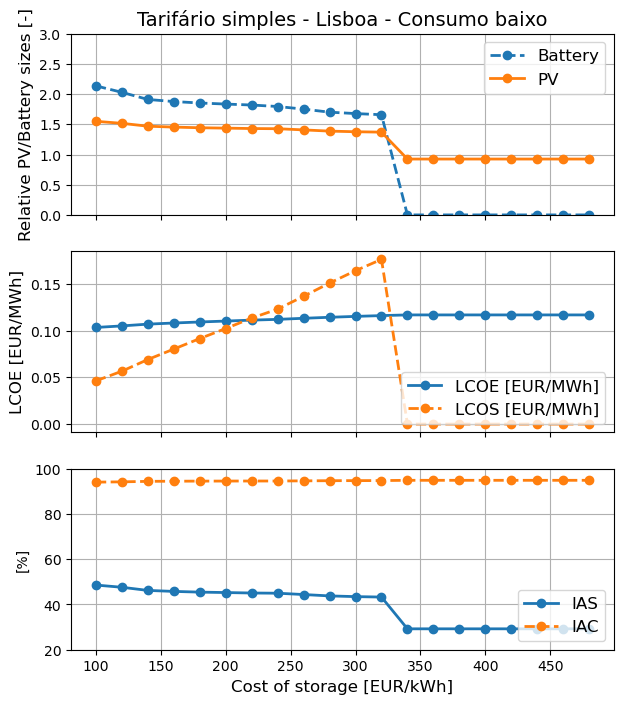

In [38]:
# Tarifário simples - Lisboa - Consumo baixo
fig4 = plt.figure(3,figsize=[7,8])
plt.subplot(311)
plt.plot(bat_lisboa_baixo_simples['custo_bateria'],bat_lisboa_baixo_simples['r_bat'],linestyle='--',linewidth=2, marker='o',label='Battery')
plt.plot(bat_lisboa_baixo_simples['custo_bateria'],bat_lisboa_baixo_simples['r_pv'],label='PV', marker='o',linewidth=2)
plt.ylabel('Relative PV/Battery sizes [-]')
plt.ylim(0,3.0)
plt.legend(fontsize=12)
plt.grid()
plt.title('Tarifário simples - Lisboa - Consumo baixo',fontsize=14)
#remove xaxis:
ax = plt.gca()
ax.set_xticklabels([])
ax.yaxis.label.set_fontsize(12)

plt.subplot(312)
plt.plot(bat_lisboa_baixo_simples['custo_bateria'],bat_lisboa_baixo_simples['LCOE'],label='LCOE [EUR/MWh]',linewidth=2, marker='o')
plt.plot(bat_lisboa_baixo_simples['custo_bateria'],bat_lisboa_baixo_simples['LCOS'],linestyle='--',linewidth=2, marker='o',label='LCOS [EUR/MWh]')
plt.ylabel('LCOE [EUR/MWh]',fontsize=12)
#plt.xlabel('Cost of storage [EUR/kWh]',fontsize=12)
plt.legend(loc=4,fontsize=12)
plt.grid()
#remove xaxis:
ax = plt.gca()
ax.set_xticklabels([])
ax.yaxis.label.set_fontsize(12)

plt.subplot(313)
plt.plot(bat_lisboa_baixo_simples['custo_bateria'], bat_lisboa_baixo_simples['ias'], label='IAS', marker='o',linewidth=2)
plt.plot(bat_lisboa_baixo_simples['custo_bateria'], bat_lisboa_baixo_simples['iac'], linestyle='--', linewidth=2, marker='o', label='IAC')
plt.xlabel('Cost of storage [EUR/kWh]',fontsize=12)
plt.ylabel('[%]')
plt.ylim([20, 100])
plt.legend(loc=4,fontsize=12)
plt.grid()


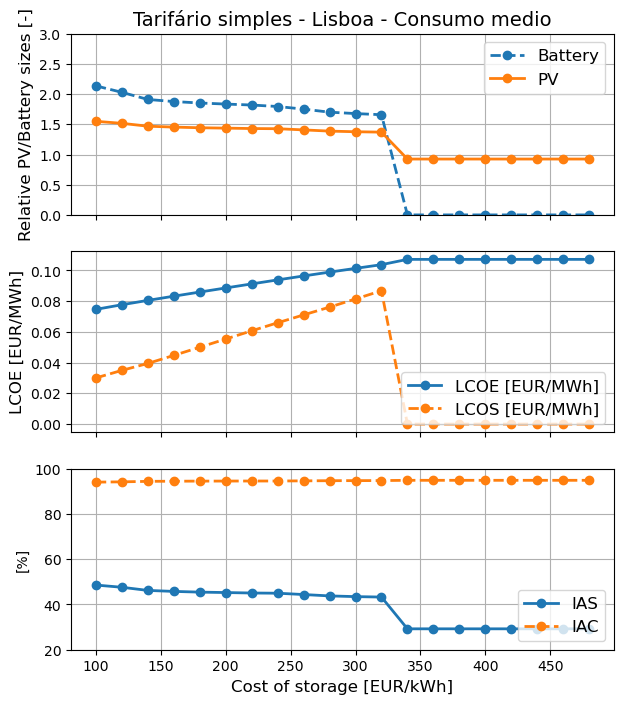

In [42]:
#Tarifário simples - Lisboa - Consumo medio
fig4 = plt.figure(3,figsize=[7,8])
plt.subplot(311)
plt.plot(bat_lisboa_medio_simples['custo_bateria'],bat_lisboa_medio_simples['r_bat'],linestyle='--',linewidth=2, marker='o',label='Battery')
plt.plot(bat_lisboa_medio_simples['custo_bateria'],bat_lisboa_medio_simples['r_pv'],label='PV', marker='o',linewidth=2)
plt.ylabel('Relative PV/Battery sizes [-]')
plt.ylim(0,3.0)
plt.legend(fontsize=12)
plt.grid()
plt.title('Tarifário simples - Lisboa - Consumo medio',fontsize=14)
#remove xaxis:
ax = plt.gca()
ax.set_xticklabels([])
ax.yaxis.label.set_fontsize(12)

plt.subplot(312)
plt.plot(bat_lisboa_medio_simples['custo_bateria'],bat_lisboa_medio_simples['LCOE'],label='LCOE [EUR/MWh]',linewidth=2, marker='o')
plt.plot(bat_lisboa_medio_simples['custo_bateria'],bat_lisboa_medio_simples['LCOS'],linestyle='--',linewidth=2, marker='o',label='LCOS [EUR/MWh]')
plt.ylabel('LCOE [EUR/MWh]',fontsize=12)
#plt.xlabel('Cost of storage [EUR/kWh]',fontsize=12)
plt.legend(loc=4,fontsize=12)
plt.grid()
#remove xaxis:
ax = plt.gca()
ax.set_xticklabels([])
ax.yaxis.label.set_fontsize(12)

plt.subplot(313)
plt.plot(bat_lisboa_medio_simples['custo_bateria'], bat_lisboa_baixo_simples['ias'], label='IAS', marker='o',linewidth=2)
plt.plot(bat_lisboa_medio_simples['custo_bateria'], bat_lisboa_baixo_simples['iac'], linestyle='--', linewidth=2, marker='o', label='IAC')
plt.xlabel('Cost of storage [EUR/kWh]',fontsize=12)
plt.ylabel('[%]')
plt.ylim([20, 100])
plt.legend(loc=4,fontsize=12)
plt.grid()

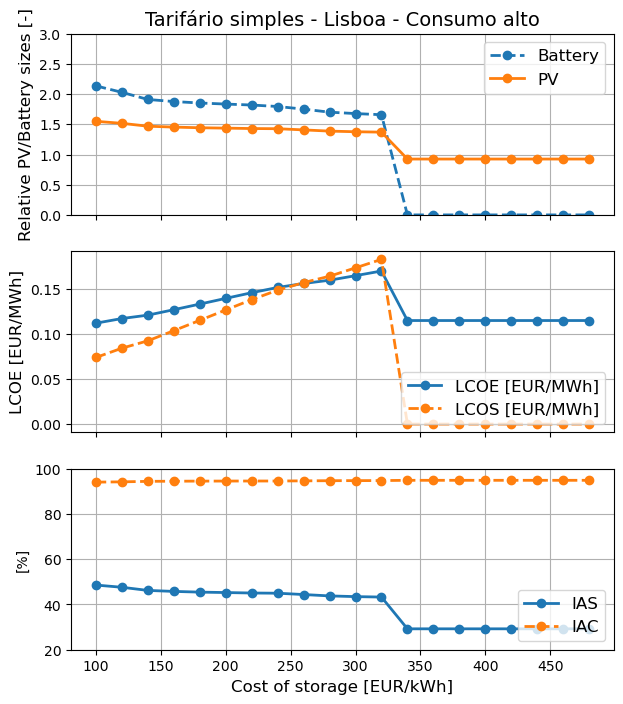

In [43]:
#Tarifário simples - Lisboa - Consumo alto
fig4 = plt.figure(3,figsize=[7,8])
plt.subplot(311)
plt.plot(bat_lisboa_alto_simples['custo_bateria'],bat_lisboa_alto_simples['r_bat'],linestyle='--',linewidth=2, marker='o',label='Battery')
plt.plot(bat_lisboa_alto_simples['custo_bateria'],bat_lisboa_alto_simples['r_pv'],label='PV', marker='o',linewidth=2)
plt.ylabel('Relative PV/Battery sizes [-]')
plt.ylim(0,3.0)
plt.legend(fontsize=12)
plt.grid()
plt.title('Tarifário simples - Lisboa - Consumo alto',fontsize=14)
#remove xaxis:
ax = plt.gca()
ax.set_xticklabels([])
ax.yaxis.label.set_fontsize(12)

plt.subplot(312)
plt.plot(bat_lisboa_alto_simples['custo_bateria'],bat_lisboa_alto_simples['LCOE'],label='LCOE [EUR/MWh]',linewidth=2, marker='o')
plt.plot(bat_lisboa_alto_simples['custo_bateria'],bat_lisboa_alto_simples['LCOS'],linestyle='--',linewidth=2, marker='o',label='LCOS [EUR/MWh]')
plt.ylabel('LCOE [EUR/MWh]',fontsize=12)
#plt.xlabel('Cost of storage [EUR/kWh]',fontsize=12)
plt.legend(loc=4,fontsize=12)
plt.grid()
#remove xaxis:
ax = plt.gca()
ax.set_xticklabels([])
ax.yaxis.label.set_fontsize(12)

plt.subplot(313)
plt.plot(bat_lisboa_alto_simples['custo_bateria'], bat_lisboa_baixo_simples['ias'], label='IAS', marker='o',linewidth=2)
plt.plot(bat_lisboa_alto_simples['custo_bateria'], bat_lisboa_baixo_simples['iac'], linestyle='--', linewidth=2, marker='o', label='IAC')
plt.xlabel('Cost of storage [EUR/kWh]',fontsize=12)
plt.ylabel('[%]')
plt.ylim([20, 100])
plt.legend(loc=4,fontsize=12)
plt.grid()